# Clasificacion de Residuos - Modelo de Machine Learning (SVM)

**Proyecto:** Clasificacion Automatica de Residuos mediante Deep Learning  
**Asignatura:** Aprendizaje Profundo  
**Entrega 2:** Modelo de Machine Learning  

---

## Objetivos del Notebook

Este notebook implementa un modelo de Machine Learning (SVM con kernel RBF) sobre caracteristicas HOG. Los objetivos son:

1. **Cargar** el dataset preprocesado y verificar su consistencia.
2. **Dividir** el conjunto en train/validacion/test de forma estratificada.
3. **Extraer** caracteristicas HOG para representar las imagenes.
4. **Entrenar** un modelo SVM con busqueda de hiperparametros.
5. **Evaluar** el rendimiento en train, validacion y test.
6. **Reportar** el numero de parametros del modelo.


In [ ]:
# =======================================
# 1. IMPORTS Y CONFIGURACION
# =======================================

import numpy as np
from pathlib import Path
import sys

# Visualizacion
import matplotlib.pyplot as plt

# Skimage
from skimage.color import rgb2gray
from skimage.feature import hog

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Agregar ruta del proyecto al path (carpeta padre de notebooks)
sys.path.insert(0, '..')

# Importar funciones de utilidad
from src.utils import initialize_project

## 2. Carga de datos y configuración

Se carga automáticamente el dataset desde el archivo .npz y se realiza la división estratificada.

In [3]:
# ========================================
# 2. CARGA DE DATOS Y CONFIGURACION
# ========================================

X_train, y_train, X_val, y_val, X_test, y_test, class_names = initialize_project()

Ejecutando en local

Cargando datos desde: /home/anuega/archivos/notebooks/../data/processed/trashnet_224x224.npz
  X.shape: (2527, 224, 224, 3)
  y.shape: (2527,)
  Clases: cardboard, glass, metal, paper, plastic, trash

División estratificada (seed=44):
  Train: 1768 imágenes (70%)
  Val:   379 imágenes (15%)
  Test:  380 imágenes (15%)


## 3. Extracción de características HOG

Los descriptores HOG se calculan dentro del pipeline durante el GridSearch.

In [4]:
# ========================================
# 3. EXTRACCION DE CARACTERISTICAS HOG
# ========================================

from sklearn.base import BaseEstimator, TransformerMixin

class HOGTransformer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
    ):
        self.orientations = orientations
        self.pixels_per_cell = pixels_per_cell
        self.cells_per_block = cells_per_block
        self.block_norm = block_norm

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []
        for img in X:
            gray = rgb2gray(img)
            feat = hog(
                gray,
                orientations=self.orientations,
                pixels_per_cell=self.pixels_per_cell,
                cells_per_block=self.cells_per_block,
                block_norm=self.block_norm,
                feature_vector=True,
            )

            features.append(feat)
        return np.array(features)


## 4. GridSearch y entrenamiento del modelo

Se entrena un SVM con kernel RBF y se optimiza el F1 macro.

In [6]:
# ========================================
# 4. GRIDSEARCH Y ENTRENAMIENTO DEL MODELO
# ========================================

pipeline = Pipeline(
    steps=[
        ('hog', HOGTransformer()),
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced')),
    ]
)

param_grid = {
    'clf__C': [0.5, 1.0, 3.0], # valores de regularización
    'clf__gamma': ['scale', 0.01, 0.001], # valores de gamma para el kernel RBF
    "hog__pixels_per_cell": [(24, 24), (32, 32)], # determina el tamaño de las celdas para HOG
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=44)
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=1,
    verbose=0,
)

print('Iniciando GridSearch ...')
grid.fit(X_train, y_train)

print('Mejores hiperparámetros:')
print(grid.best_params_)
print(f'Mejor F1 macro (CV): {grid.best_score_:.4f}')

best_model = grid.best_estimator_

Iniciando GridSearch ...
Mejores hiperparámetros:
{'clf__C': 3.0, 'clf__gamma': 'scale', 'hog__pixels_per_cell': (32, 32)}
Mejor F1 macro (CV): 0.5726


## 5. Función de evaluación

Se define una función unificada para calcular métricas clave y generar el reporte de clasificación por clase.

In [7]:
def evaluate_model(model, X, y, split_name):
    y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y, y_pred,
        average='macro',
        zero_division=0
    )

    print(f"\nResultados en {split_name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y, y_pred,
        target_names=class_names,
        zero_division=0
    ))

    return acc, prec, rec, f1

## 6. Evaluación en particiones

Se evalúa el mejor modelo del GridSearch en train, validación y test.

In [9]:
results_train = evaluate_model(best_model, X_train, y_train, 'TRAIN')
results_val = evaluate_model(best_model, X_val, y_val, 'VALIDACION')
results_test = evaluate_model(best_model, X_test, y_test, 'TEST')


Resultados en TRAIN:
  Accuracy:  0.9972
  Precision: 0.9975
  Recall:    0.9975
  F1-score:  0.9975

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.99      1.00      1.00       282
       glass       0.99      1.00      1.00       350
       metal       1.00      0.99      1.00       287
       paper       1.00      1.00      1.00       416
     plastic       1.00      1.00      1.00       337
       trash       1.00      1.00      1.00        96

    accuracy                           1.00      1768
   macro avg       1.00      1.00      1.00      1768
weighted avg       1.00      1.00      1.00      1768


Resultados en VALIDACION:
  Accuracy:  0.6491
  Precision: 0.6639
  Recall:    0.6209
  F1-score:  0.6347

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.76      0.74      0.75        61
       glass       0.68      0.73      0.71        75
       metal       0.57      0.48    

### 6.1. Visualización de Resultados
Se presentan las matrices de confusión para analizar los errores por clase y un gráfico comparativo de las métricas para detectar posible overfitting.

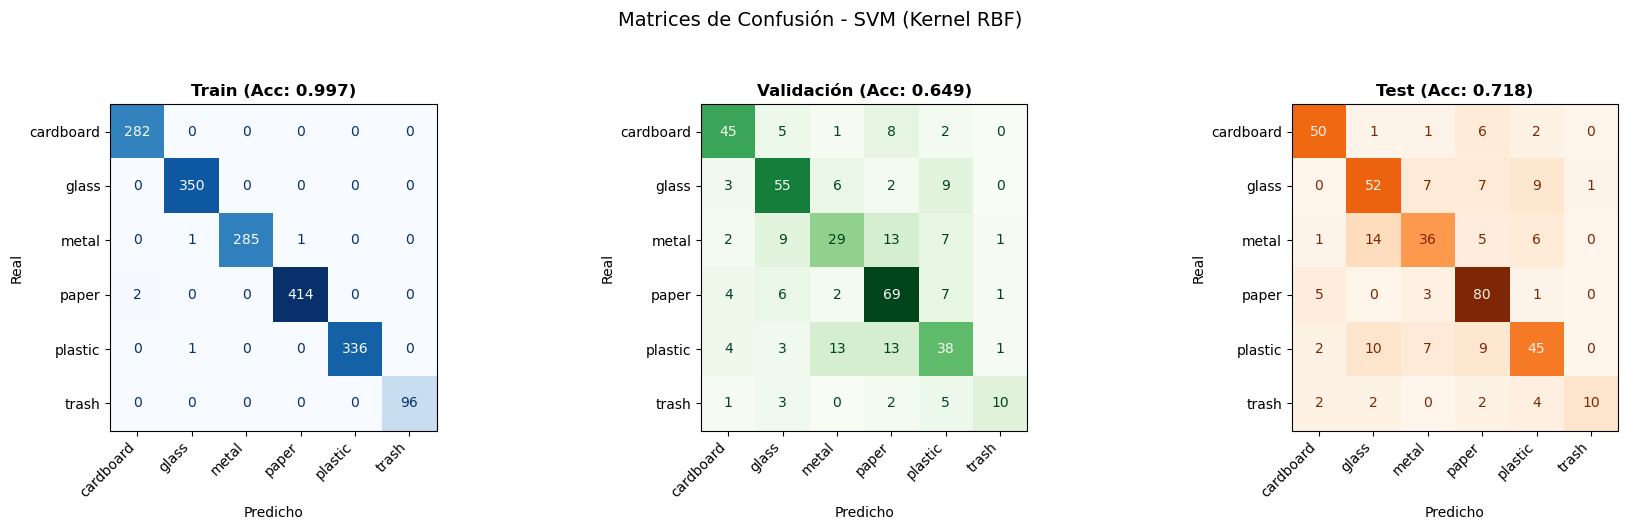

In [10]:
# =================================
# 6.1. MATRICES DE CONFUSION 
# =================================

# 1. Generar predicciones para todas las particiones
y_pred_train = best_model.predict(X_train)
y_pred_val   = best_model.predict(X_val)
y_pred_test  = best_model.predict(X_test)

# --- MATRICES DE CONFUSIÓN ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

partitions = [
    (y_train, y_pred_train, 'Train', results_train[0], 'Blues'),
    (y_val,   y_pred_val,   'Validación', results_val[0],   'Greens'),
    (y_test,  y_pred_test,  'Test', results_test[0],  'Oranges')
]

for ax, (y_true, y_pred, name, acc, cmap) in zip(axes, partitions):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    
    ax.set_title(f"{name} (Acc: {acc:.3f})", fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicho", fontsize=10)
    ax.set_ylabel("Real", fontsize=10)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle(f"Matrices de Confusión - SVM (Kernel RBF)", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


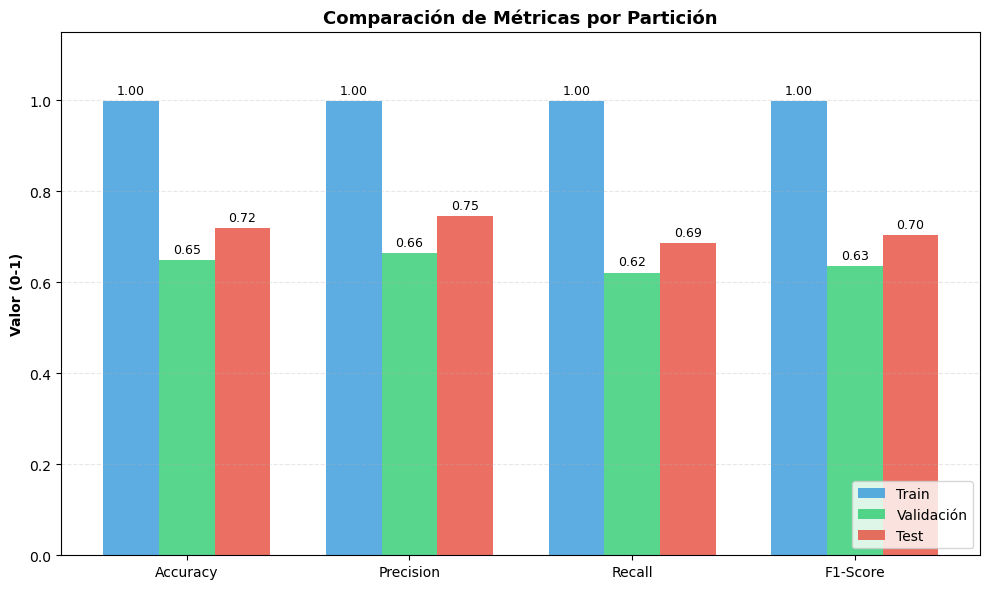

Análisis de Generalización:
  Diferencia Accuracy (Train - Test): 0.2788
  -> Pobre generalización (Overfitting severo).


In [11]:
# =================================
# 6.2. COMPARACIÓN DE MÉTRICAS
# =================================
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, results_train, width, label='Train', color='#3498db', alpha=0.8)
rects2 = ax.bar(x, results_val, width, label='Validación', color='#2ecc71', alpha=0.8)
rects3 = ax.bar(x + width, results_test, width, label='Test', color='#e74c3c', alpha=0.8)

# Añadir etiquetas de valor sobre las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

ax.set_ylabel('Valor (0-1)', fontweight='bold')
ax.set_title('Comparación de Métricas por Partición', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Análisis textual de generalización
diff_acc = results_train[0] - results_test[0]
print(f"Análisis de Generalización:")
print(f"  Diferencia Accuracy (Train - Test): {diff_acc:.4f}")
if diff_acc < 0.05:
    print("  -> Excelente generalización (Poco overfitting).")
elif diff_acc < 0.15:
    print("  -> Generalización aceptable (Overfitting moderado).")
else:
    print("  -> Pobre generalización (Overfitting severo).")

### 6.2. Visualización de Errores en Test

Muestra ejemplos concretos de imágenes del conjunto de Test que el modelo clasificó incorrectamente para entender las debilidades del clasificador.

Resumen de errores en Test:
  Total muestras: 380
  Errores: 107 (28.16%)


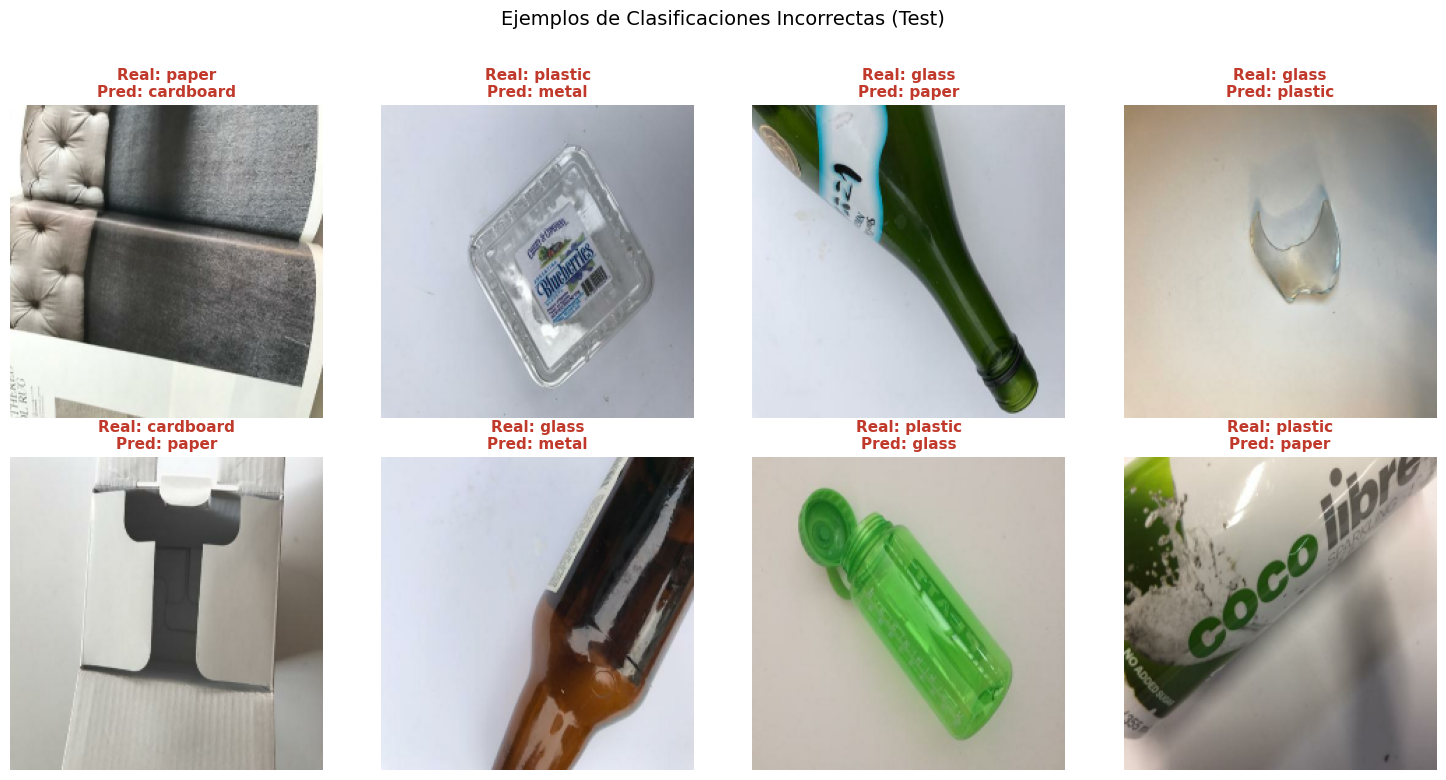


Confusiones más frecuentes (Real -> Predicho):
  metal        -> glass        : 14 veces
  plastic      -> glass        : 10 veces
  plastic      -> paper        : 9 veces
  glass        -> plastic      : 9 veces
  glass        -> paper        : 7 veces


In [ ]:
# =======================================
# 6.2. VISUALIZACION DE ERRORES
# ========================================

# Identificar índices de errores
mis_idx = np.where(y_pred_test != y_test)[0]
total_test = len(y_test)
num_errors = len(mis_idx)

print(f"Resumen de errores en Test:")
print(f"  Total muestras: {total_test}")
print(f"  Errores: {num_errors} ({num_errors/total_test*100:.2f}%)")

if num_errors > 0:
    # Mostrar hasta 8 ejemplos de error aleatorios
    show_n = min(8, num_errors)
    
    np.random.seed(42) 
    chosen_errors = np.random.choice(mis_idx, size=show_n, replace=False)
    
    cols = 4
    rows = int(np.ceil(show_n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.8 * rows))
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, idx) in enumerate(zip(axes, chosen_errors)):
        img = X_test[idx].astype(np.uint8)
        true_lbl = class_names[y_test[idx]]
        pred_lbl = class_names[y_pred_test[idx]]
        
        ax.imshow(img)
        # Título en rojo indicando el error
        ax.set_title(f"Real: {true_lbl}\nPred: {pred_lbl}", 
                     color='#c0392b', fontsize=11, fontweight='bold')
        ax.axis('off')
        
    # Ocultar ejes vacíos si hay menos de 8 errores
    for ax in axes[show_n:]:
        ax.axis('off')
        
    plt.suptitle("Ejemplos de Clasificaciones Incorrectas (Test)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Mostrar pares de confusión más frecuentes
    print("\nConfusiones más frecuentes (Real -> Predicho):")
    error_pairs = [(class_names[y_test[i]], class_names[y_pred_test[i]]) for i in mis_idx]
    from collections import Counter
    most_common = Counter(error_pairs).most_common(5)
    
    for (real, pred), count in most_common:
        print(f"  {real:12} -> {pred:12} : {count} veces")

## 7. Número de parámetros del modelo (aprox.)

Para SVM con kernel RBF no hay una matriz de pesos explícita. Se reporta un conteo aproximado basado en el número de support vectors y el número de features HOG.

In [13]:
clf = best_model.named_steps['clf']
n_support = int(np.sum(clf.n_support_))
n_features = int(clf.support_vectors_.shape[1])
param_count = n_support * (n_features + 1)

print(f'Número de support vectors: {n_support}')
print(f'Número de features HOG: {n_features}')
print(f'Número de parámetros aprox.: {param_count:,}')

Número de support vectors: 1683
Número de features HOG: 1296
Número de parámetros aprox.: 2,182,851


## 8. Explicabilidad (support vectors y casos dudosos)

Visualizamos los **Vectores de Soporte**, que son las imágenes críticas que definen la frontera de decisión entre residuos. Además, analizamos los casos de **menor margen**, que nos permiten ver con qué imágenes el modelo tuvo **mayor incertidumbre** o confusión, ayudándonos a entender la complejidad real del dataset.

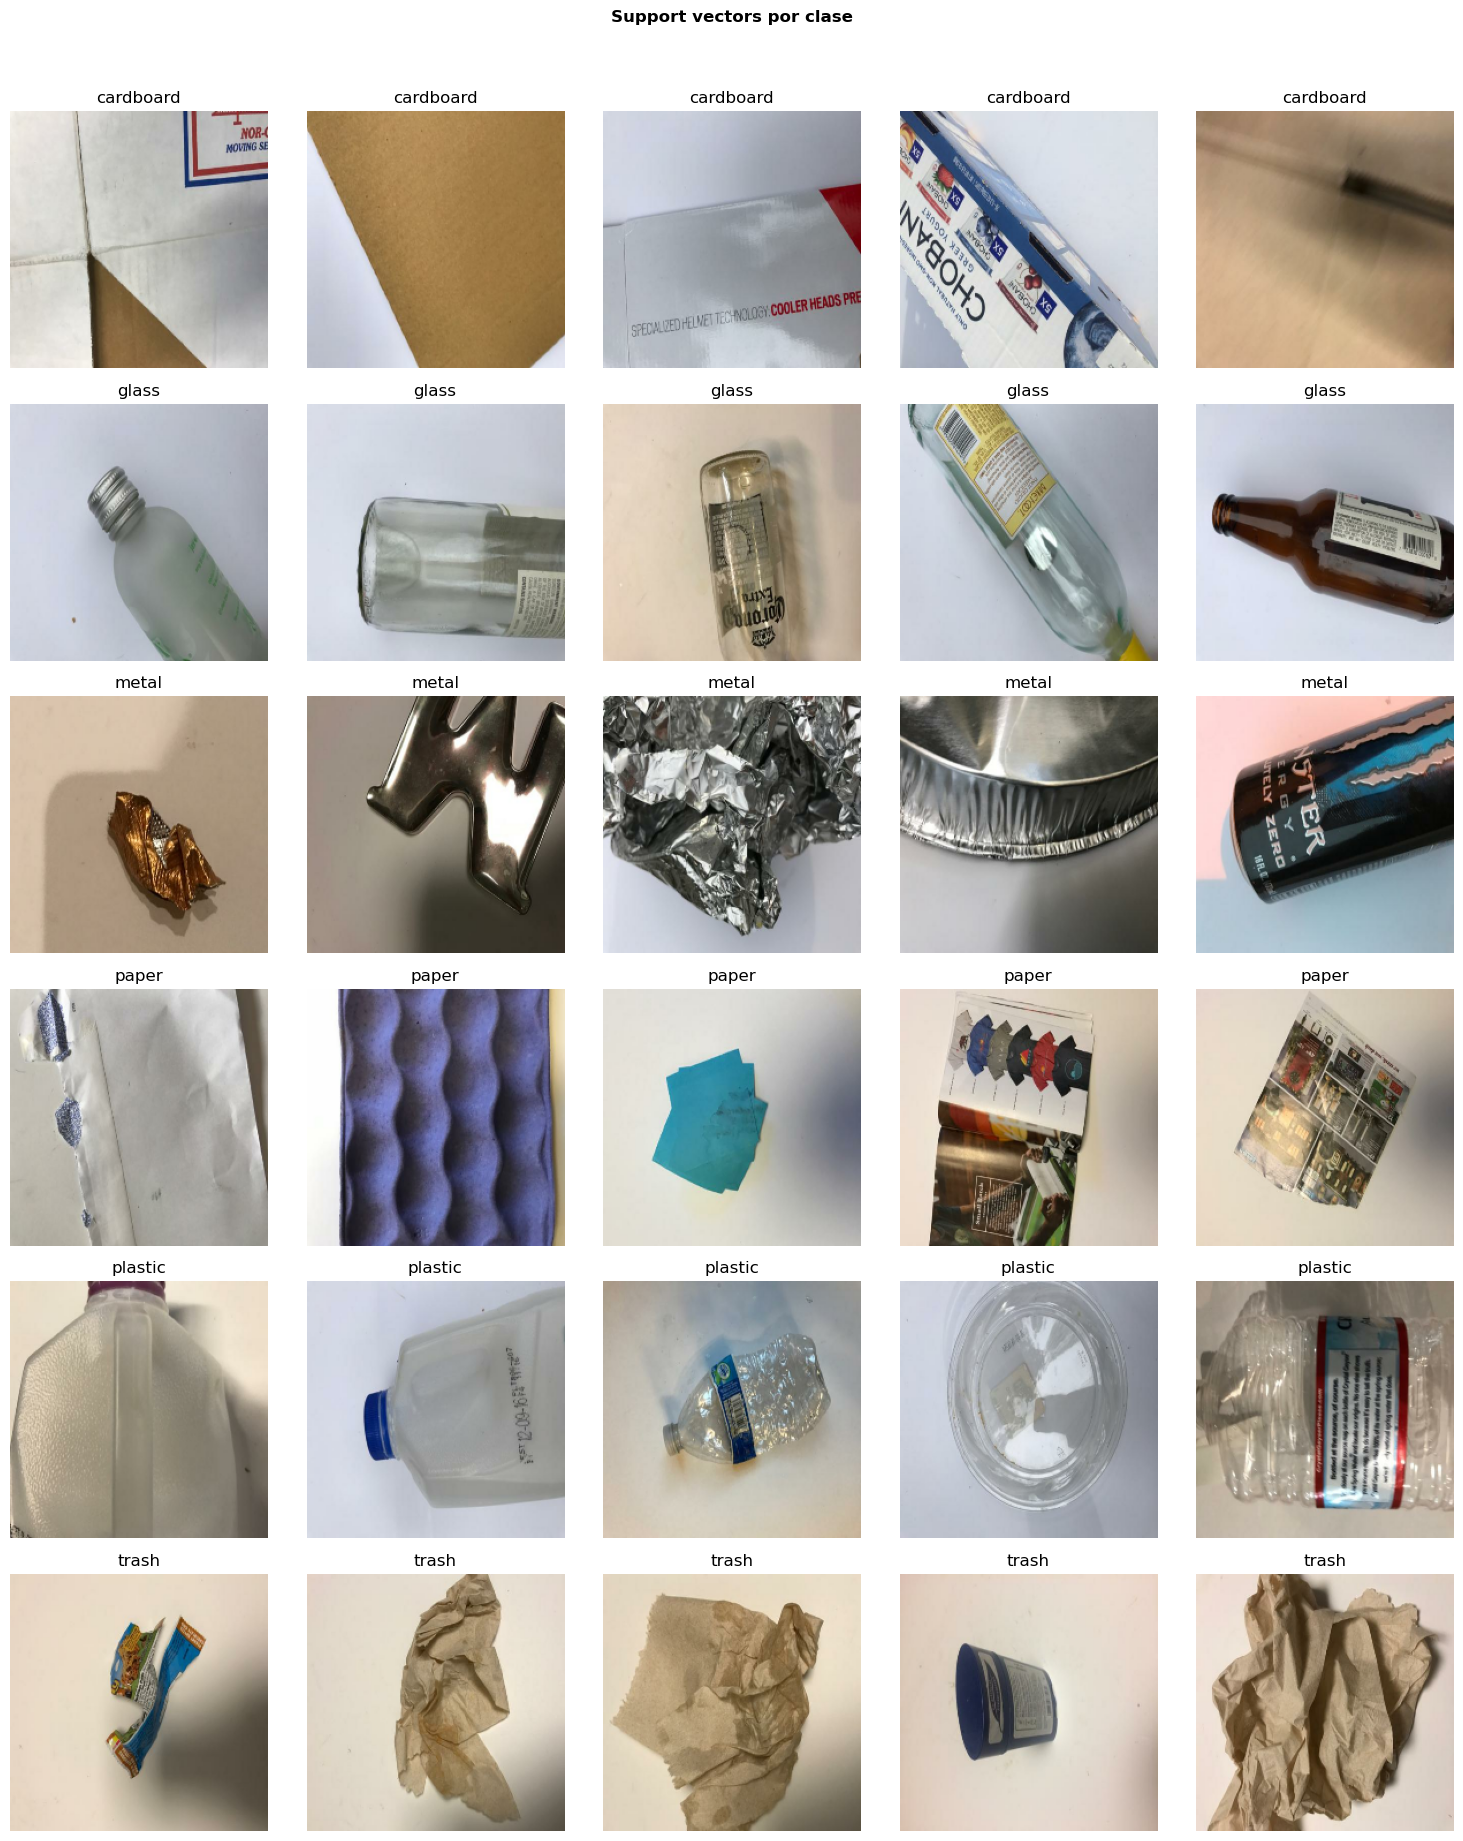

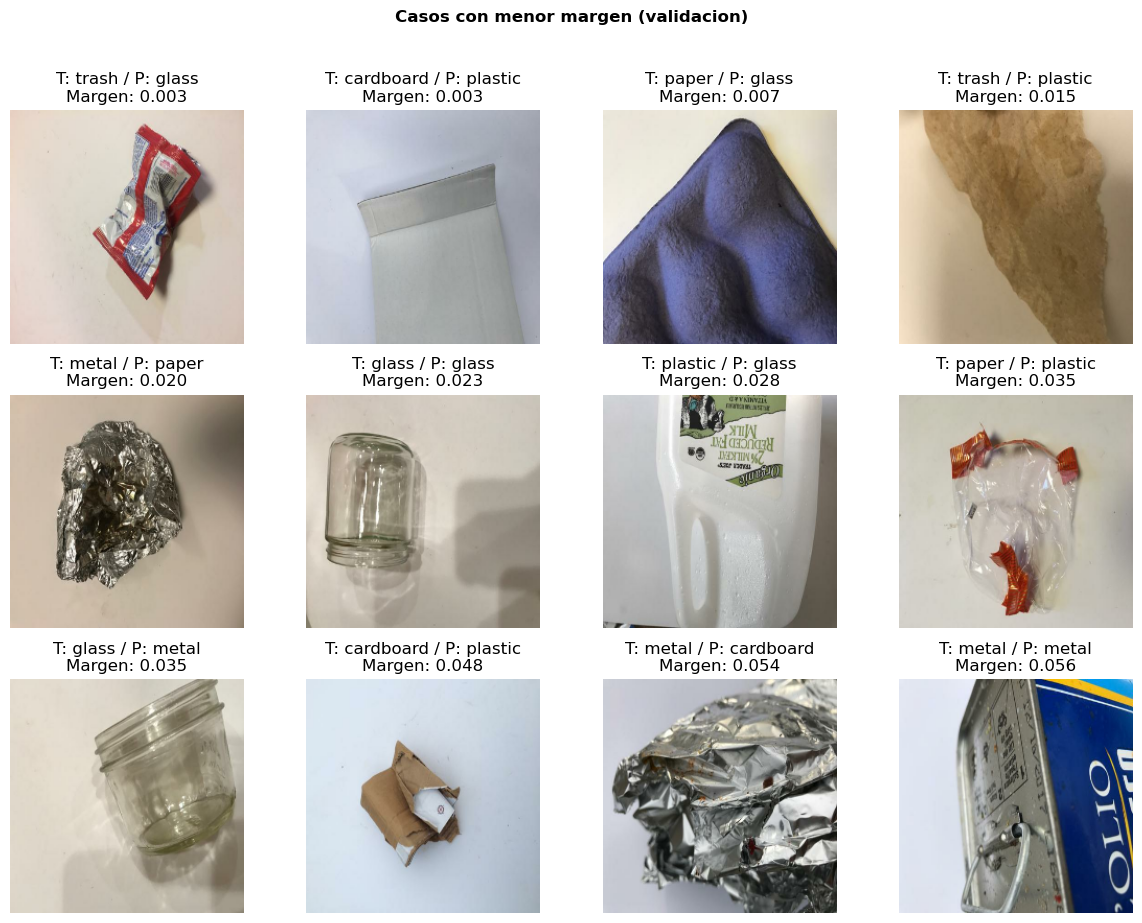

In [14]:
# Support vectors por clase
clf = best_model.named_steps['clf']
sv_idx = clf.support_
sv_labels = y_train[sv_idx]

samples_per_class = 5
num_classes = len(class_names)
fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(3 * samples_per_class, 3 * num_classes))

if num_classes == 1:
    axes = np.array([axes])

for class_idx in range(num_classes):
    class_sv = sv_idx[sv_labels == class_idx]
    if len(class_sv) == 0:
        for j in range(samples_per_class):
            axes[class_idx, j].axis('off')
        continue

    chosen = np.random.choice(class_sv, size=min(samples_per_class, len(class_sv)), replace=False)
    for j in range(samples_per_class):
        ax = axes[class_idx, j]
        if j < len(chosen):
            img = X_train[chosen[j]].astype(np.uint8)
            ax.imshow(img)
            ax.set_title(class_names[class_idx])
        ax.axis('off')

plt.suptitle('Support vectors por clase', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Casos con menor margen en validacion
scores = best_model.decision_function(X_val)
if scores.ndim == 1:
    margins = np.abs(scores)
    pred = (scores > 0).astype(int)
else:
    sorted_scores = np.sort(scores, axis=1)
    margins = sorted_scores[:, -1] - sorted_scores[:, -2]
    pred = np.argmax(scores, axis=1)

k = min(12, len(X_val))
idx = np.argsort(margins)[:k]
cols = 4
rows = int(np.ceil(k / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
axes = np.array(axes).reshape(-1)

for ax, i in zip(axes, idx):
    img = X_val[i].astype(np.uint8)
    true_lbl = class_names[y_val[i]]
    pred_lbl = class_names[pred[i]]
    ax.imshow(img)
    ax.set_title(f'T: {true_lbl} / P: {pred_lbl}\nMargen: {margins[i]:.3f}')
    ax.axis('off')

for ax in axes[k:]:
    ax.axis('off')

plt.suptitle('Casos con menor margen (validacion)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Resumen final

Resumen compacto con las métricas del mejor modelo encontrado por GridSearch.

In [15]:
print('\nRESUMEN FINAL (SVM + HOG)')
print(f'  Train -> Acc: {results_train[0]:.4f}, F1: {results_train[3]:.4f}')
print(f'  Val   -> Acc: {results_val[0]:.4f}, F1: {results_val[3]:.4f}')
print(f'  Test  -> Acc: {results_test[0]:.4f}, F1: {results_test[3]:.4f}')
print(f'  Params aprox.: {param_count:,}')


RESUMEN FINAL (SVM + HOG)
  Train -> Acc: 0.9972, F1: 0.9975
  Val   -> Acc: 0.6491, F1: 0.6347
  Test  -> Acc: 0.7184, F1: 0.7035
  Params aprox.: 2,182,851
